# Pizza Sales Analysis (2015)
**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn)

**Dataset:** one year of order-line data from a pizza restaurant (48,620 rows, 12 columns, Kaggle).

**Business questions**
1. How much revenue, orders and pizzas did the business make, and what is the average order value?
2. When is demand highest (hour, weekday, month)?
3. Which categories, sizes and pizzas drive revenue, and which underperform?

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import matplotlib.ticker as mtick
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({'figure.dpi': 110, 'axes.titleweight': 'bold'})
import os; os.makedirs('../images', exist_ok=True)

df = pd.read_csv('../data/pizza_sales.csv')
df.head(3)

,pizza_id,order_id,pizza_name_id,quantity,order_date,order_time,unit_price,total_price,pizza_size,pizza_category,pizza_ingredients,pizza_name
0,1,1,hawaiian_m,1,01-01-2015,11:38:36,13.25,13.25,M,Classic,"Sliced Ham, Pineapple, Mozzarella Cheese",The Hawaiian Pizza
1,2,2,classic_dlx_m,1,01-01-2015,11:57:40,16.00,16.00,M,Classic,"Pepperoni, Mushrooms, Red Onions, Red Peppers,...",The Classic Deluxe Pizza
2,3,2,five_cheese_l,1,01-01-2015,11:57:40,18.50,18.50,L,Veggie,"Mozzarella Cheese, Provolone Cheese, Smoked Go...",The Five Cheese Pizza


## 1. Data cleaning and quality checks

In [2]:
# dates are dd-mm-yyyy in the source file
df['order_date'] = pd.to_datetime(df['order_date'], format='%d-%m-%Y')
df['order_dt'] = pd.to_datetime(df['order_date'].dt.strftime('%Y-%m-%d') + ' ' + df['order_time'])
df['month'] = df['order_date'].dt.month_name()
df['month_num'] = df['order_date'].dt.month
df['weekday'] = df['order_date'].dt.day_name()
df['hour'] = df['order_dt'].dt.hour

print('Shape:', df.shape)
print('Nulls:', df.isna().sum().sum(), '| duplicate pizza_id:', df['pizza_id'].duplicated().sum())
print('Date range:', df['order_date'].min().date(), 'to', df['order_date'].max().date(), '| trading days:', df['order_date'].nunique())
print('total_price = unit_price x quantity everywhere:', ((df['unit_price'] * df['quantity'] - df['total_price']).abs() < 0.01).all())
print('Each order has one date and one time:', (df.groupby('order_id')[['order_date', 'order_time']].nunique() == 1).all().all())

Shape: (48620, 17)
Nulls: 0 | duplicate pizza_id: 0
Date range: 2015-01-01 to 2015-12-31 | trading days: 358
total_price = unit_price x quantity everywhere: True
Each order has one date and one time: True


The data is clean: no nulls or duplicate line IDs, prices reconcile, and each order has a single timestamp. The file has **358 trading days**, so a few days have no orders; daily averages below use trading days only.

## 2. KPIs

In [3]:
total_revenue = df['total_price'].sum()
total_orders = df['order_id'].nunique()
total_pizzas = df['quantity'].sum()
aov = total_revenue / total_orders
ppo = total_pizzas / total_orders
pd.Series({'Total Revenue ($)': round(total_revenue, 2), 'Total Orders': total_orders,
           'Total Pizzas Sold': total_pizzas, 'Average Order Value ($)': round(aov, 2),
           'Avg Pizzas per Order': round(ppo, 2)})

Total Revenue ($)          817860.05
Total Orders                21350.00
Total Pizzas Sold           49574.00
Average Order Value ($)        38.31
Avg Pizzas per Order            2.32
dtype: float64

## 3. Time trends

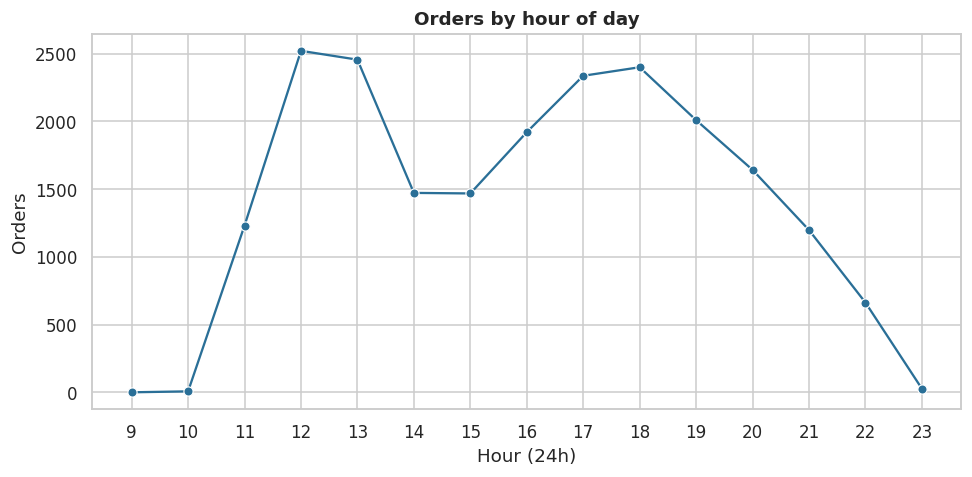

,pizzas,revenue,orders
hour,,,
12,6776,111877.90,2520
13,6413,106065.70,2455
18,5417,89296.85,2399
17,5211,86237.45,2336
19,4406,72628.90,2009


In [4]:
orders = df.drop_duplicates('order_id')   # one row per order

# Hourly
hourly = df.groupby('hour').agg(pizzas=('quantity', 'sum'), revenue=('total_price', 'sum'))
hourly['orders'] = orders.groupby('hour').size()
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.lineplot(x=hourly.index, y=hourly['orders'], marker='o', ax=ax, color='#2a6f97')
ax.set_title('Orders by hour of day'); ax.set_xlabel('Hour (24h)'); ax.set_ylabel('Orders'); ax.set_xticks(hourly.index)
plt.tight_layout(); plt.savefig('../images/01_hourly.png'); plt.show()
hourly.sort_values('orders', ascending=False).head(5)

,orders,revenue,trading_days,orders_per_day
weekday,,,,
Monday,2794,107329.55,48,58.2
Tuesday,2973,114133.80,52,57.2
Wednesday,3024,114408.40,52,58.2
Thursday,3239,123528.50,52,62.3
Friday,3538,136073.90,50,70.8
Saturday,3158,123182.40,52,60.7
Sunday,2624,99203.50,52,50.5


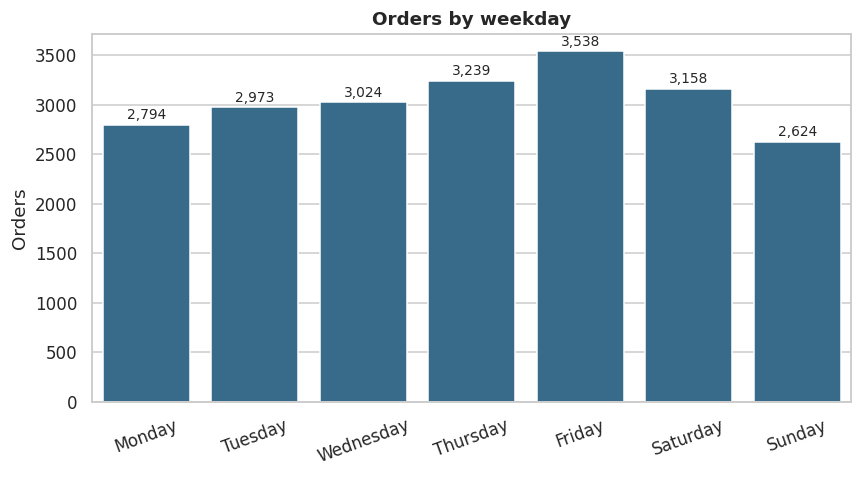

In [5]:
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
wk = orders.groupby('weekday').size().reindex(days).to_frame('orders')
wk['revenue'] = df.groupby('weekday')['total_price'].sum().reindex(days)
wk['trading_days'] = df.groupby('weekday')['order_date'].nunique().reindex(days)
wk['orders_per_day'] = (wk['orders'] / wk['trading_days']).round(1)
display(wk)
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=wk.index, y=wk['orders'], ax=ax, color='#2a6f97')
for i, v in enumerate(wk['orders']): ax.text(i, v + 60, f'{v:,}', ha='center', fontsize=9)
ax.set_title('Orders by weekday'); ax.set_xlabel(''); ax.set_ylabel('Orders')
plt.xticks(rotation=20); plt.tight_layout(); plt.savefig('../images/02_weekday.png'); plt.show()

,orders,pizzas,revenue
month,,,
January,1845,4232,69793.0
February,1685,3961,65160.0
March,1840,4261,70397.0
April,1799,4151,68737.0
May,1853,4328,71403.0
June,1773,4107,68230.0
July,1935,4392,72558.0
August,1841,4168,68278.0
September,1661,3890,64180.0


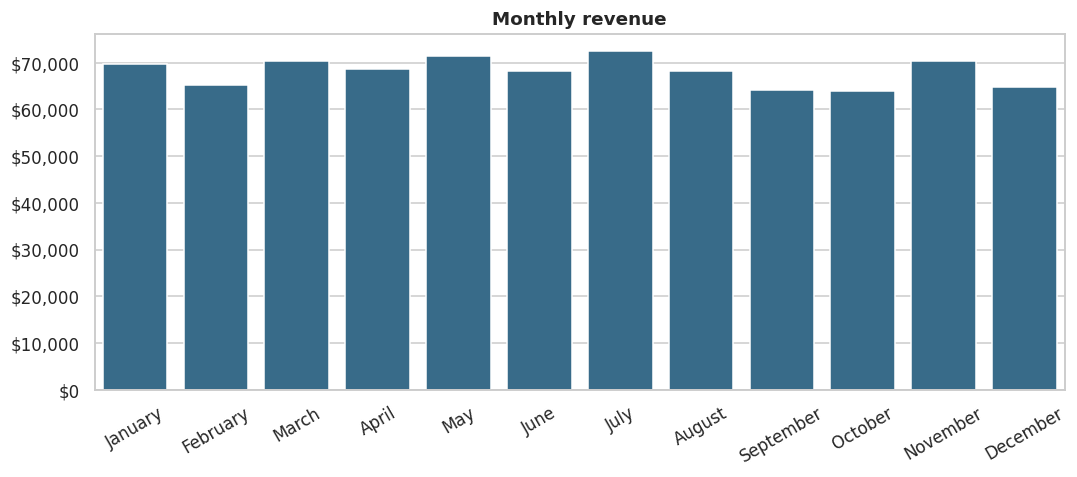

In [6]:
mo = df.groupby(['month_num', 'month']).agg(revenue=('total_price', 'sum'), pizzas=('quantity', 'sum')).reset_index().set_index('month')
mo['orders'] = orders.groupby('month').size()
mo = mo.sort_values('month_num')
display(mo[['orders', 'pizzas', 'revenue']].round(0))
fig, ax = plt.subplots(figsize=(10, 4.5))
sns.barplot(x=mo.index, y=mo['revenue'], ax=ax, color='#2a6f97')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_title('Monthly revenue'); ax.set_xlabel(''); ax.set_ylabel('')
plt.xticks(rotation=30); plt.tight_layout(); plt.savefig('../images/03_monthly_revenue.png'); plt.show()

## 4. Category and size

,revenue,pizzas,revenue_share_%,pizzas_share_%
pizza_category,,,,
Classic,220053.10,14888,26.91,30.03
Supreme,208197.00,11987,25.46,24.18
Chicken,195919.50,11050,23.96,22.29
Veggie,193690.45,11649,23.68,23.50


,revenue,pizzas,revenue_share_%
pizza_size,,,
S,178076.50,14403,21.77
M,249382.25,15635,30.49
L,375318.70,18956,45.89
XL,14076.00,552,1.72
XXL,1006.60,28,0.12


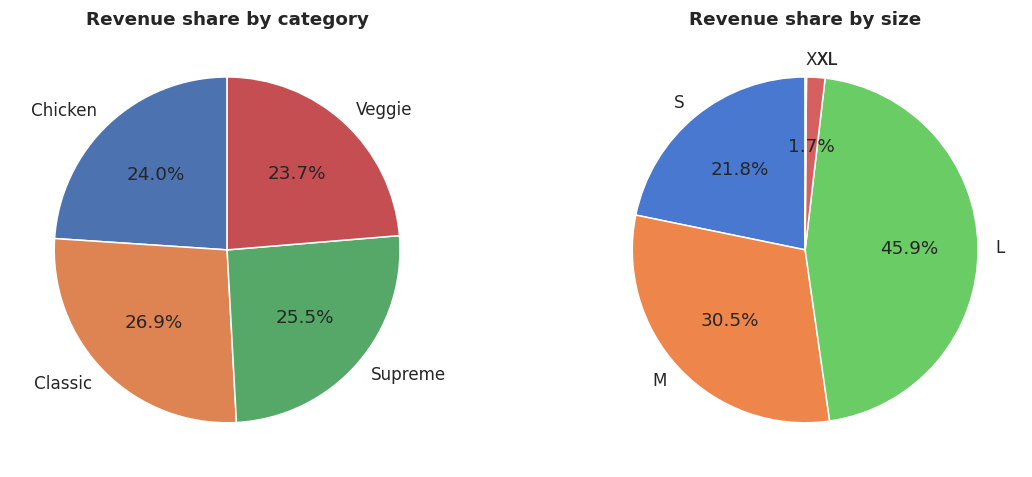

In [7]:
cat = df.groupby('pizza_category').agg(revenue=('total_price', 'sum'), pizzas=('quantity', 'sum'))
cat['revenue_share_%'] = (cat['revenue'] / cat['revenue'].sum() * 100).round(2)
cat['pizzas_share_%'] = (cat['pizzas'] / cat['pizzas'].sum() * 100).round(2)
display(cat.sort_values('revenue', ascending=False))

size = df.groupby('pizza_size').agg(revenue=('total_price', 'sum'), pizzas=('quantity', 'sum')).reindex(['S', 'M', 'L', 'XL', 'XXL'])
size['revenue_share_%'] = (size['revenue'] / size['revenue'].sum() * 100).round(2)
display(size)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].pie(cat['revenue'], labels=cat.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('deep'))
ax[0].set_title('Revenue share by category')
ax[1].pie(size['revenue'], labels=size.index, autopct=lambda p: f'{p:.1f}%' if p > 1 else '', startangle=90, colors=sns.color_palette('muted'))
ax[1].set_title('Revenue share by size')
plt.tight_layout(); plt.savefig('../images/04_category_size.png'); plt.show()

## 5. Best and worst sellers

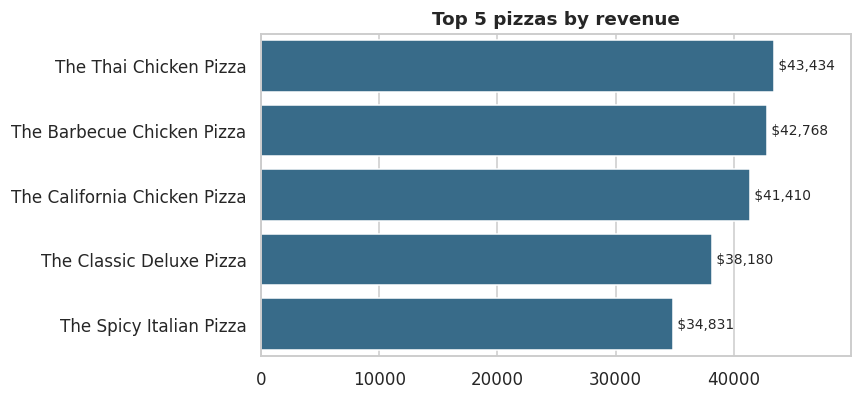

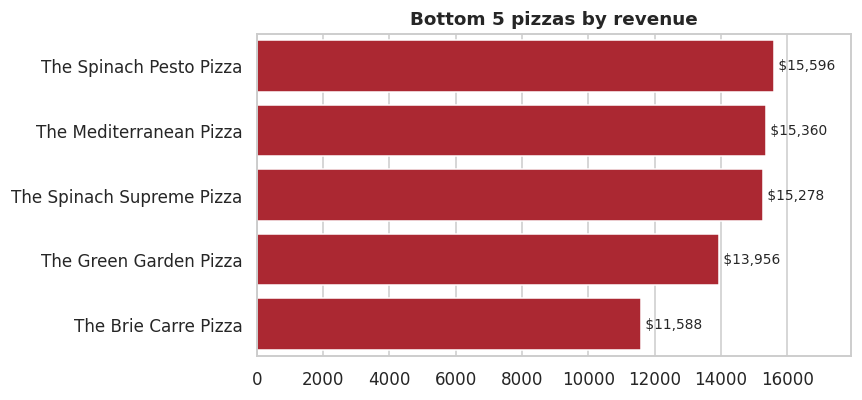

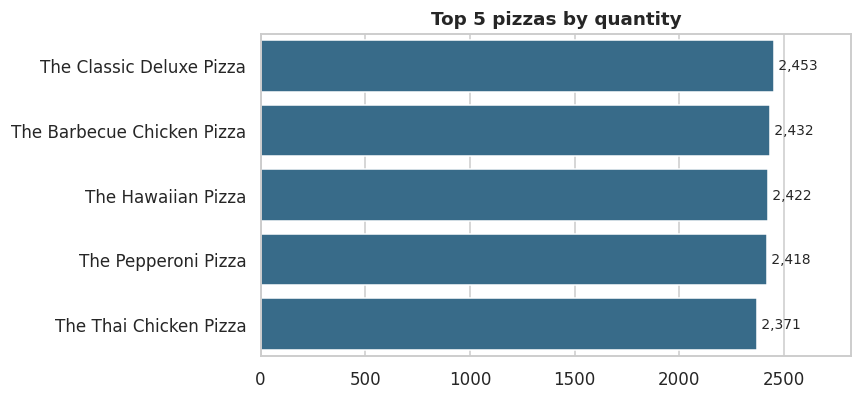

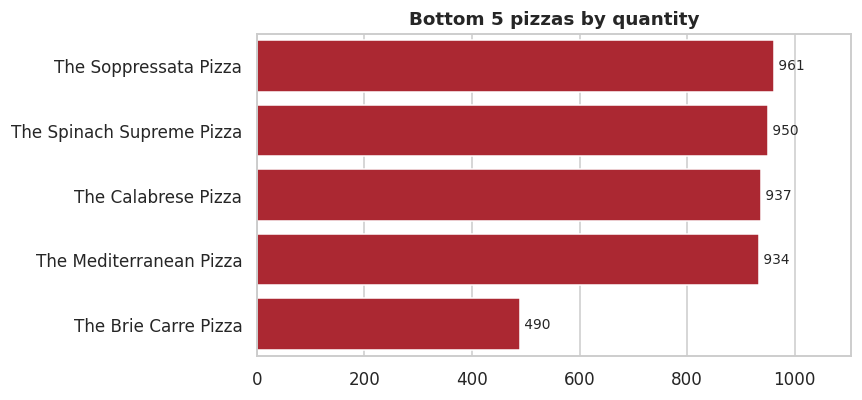

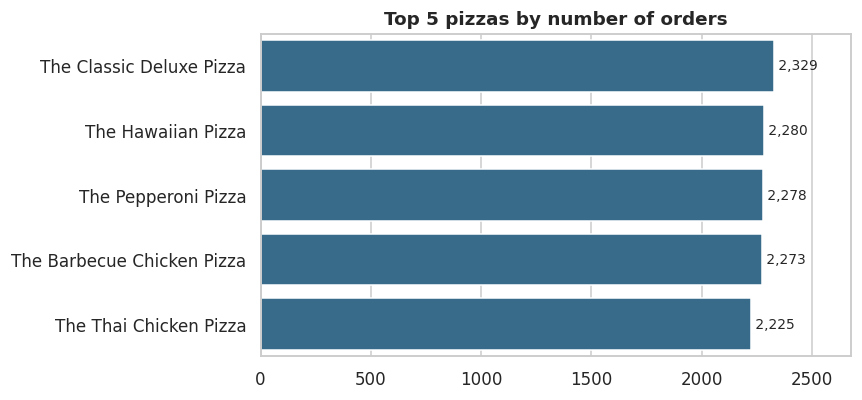

In [8]:
pz = df.groupby('pizza_name').agg(revenue=('total_price', 'sum'), pizzas=('quantity', 'sum'), orders=('order_id', 'nunique'))
def barh(s, title, fname, fmt, color):
    fig, ax = plt.subplots(figsize=(8, 3.8))
    sns.barplot(x=s.values, y=s.index, ax=ax, color=color)
    for i, v in enumerate(s.values): ax.text(v, i, ' ' + fmt(v), va='center', fontsize=9)
    ax.set_title(title); ax.set_ylabel(''); ax.set_xlabel(''); ax.margins(x=0.15)
    plt.tight_layout(); plt.savefig(f'../images/{fname}.png'); plt.show()

barh(pz['revenue'].nlargest(5), 'Top 5 pizzas by revenue', '05_top_revenue', lambda v: f'${v:,.0f}', '#2a6f97')
barh(pz['revenue'].nsmallest(5).sort_values(ascending=False), 'Bottom 5 pizzas by revenue', '06_bottom_revenue', lambda v: f'${v:,.0f}', '#c1121f')
barh(pz['pizzas'].nlargest(5), 'Top 5 pizzas by quantity', '07_top_quantity', lambda v: f'{v:,.0f}', '#2a6f97')
barh(pz['pizzas'].nsmallest(5).sort_values(ascending=False), 'Bottom 5 pizzas by quantity', '08_bottom_quantity', lambda v: f'{v:,.0f}', '#c1121f')
barh(pz['orders'].nlargest(5), 'Top 5 pizzas by number of orders', '09_top_orders', lambda v: f'{v:,.0f}', '#2a6f97')

In [9]:
# Pareto: how concentrated is revenue?
p = pz['revenue'].sort_values(ascending=False)
cum = p.cumsum() / p.sum() * 100
print(f'Top 10 of {len(p)} pizzas generate {cum.iloc[9]:.1f}% of revenue')
print(f'Bottom 10 pizzas generate {p.tail(10).sum() / p.sum() * 100:.1f}% of revenue')

Top 10 of 32 pizzas generate 44.5% of revenue
Bottom 10 pizzas generate 18.8% of revenue


## 6. Basket behaviour

In [10]:
basket = df.groupby('order_id').agg(pizzas=('quantity', 'sum'), value=('total_price', 'sum'))
print(basket['pizzas'].describe().round(2))
print(f"\nShare of orders with 1 pizza: {(basket['pizzas'] == 1).mean() * 100:.1f}%  |  with 3+: {(basket['pizzas'] >= 3).mean() * 100:.1f}%")
print(f"Median order value ${basket['value'].median():.2f}  vs mean ${basket['value'].mean():.2f}")

count    21350.00
mean         2.32
std          1.83
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         28.00
Name: pizzas, dtype: float64

Share of orders with 1 pizza: 38.0%  |  with 3+: 33.2%
Median order value $32.50  vs mean $38.31


## 7. Findings

In [11]:
peak = hourly['orders'].idxmax(); lunch = hourly.loc[12:13, 'orders'].sum() / hourly['orders'].sum() * 100
print(f"Total revenue ${total_revenue:,.0f} from {total_orders:,} orders ({total_pizzas:,} pizzas); AOV ${aov:.2f}")
print(f"Peak hour: {peak}:00 | 12:00-13:59 share of all orders: {lunch:.1f}%")
print('Busiest weekday by orders:', wk['orders'].idxmax(), '| quietest:', wk['orders'].idxmin())
print('Best month by revenue:', mo['revenue'].idxmax(), '| weakest:', mo['revenue'].idxmin())
print('Top category by revenue:', cat['revenue'].idxmax(), f"({cat['revenue_share_%'].max()}%)")
print('Top pizza by revenue:', pz['revenue'].idxmax(), '| lowest:', pz['revenue'].idxmin())

Total revenue $817,860 from 21,350 orders (49,574 pizzas); AOV $38.31
Peak hour: 12:00 | 12:00-13:59 share of all orders: 23.3%
Busiest weekday by orders: Friday | quietest: Sunday
Best month by revenue: July | weakest: October
Top category by revenue: Classic (26.91%)
Top pizza by revenue: The Thai Chicken Pizza | lowest: The Brie Carre Pizza


### Recommendations
1. **Staff and prep for the lunch and early-evening peaks** shown in the hourly chart; schedule promotions in the quiet hours.
2. **Match staffing to weekday demand:** Friday is the busiest day (about 71 orders per trading day) and Sunday the quietest (about 51); test offers on the slow days.
3. **Review the bottom-5 pizzas** by revenue and quantity for menu simplification, bundling or repricing.
4. **Raise basket size:** most orders contain one or two pizzas, so combo deals and sides are the obvious AOV lever.
5. **Limitations:** one year of one restaurant, no customer IDs, costs or margins, so results describe sales, not profit.